# 00 — Data Quality Assessment & Leakage Audit

**Giai đoạn 1 trong quy trình Data Science chuẩn công nghiệp**: Kiểm định chất lượng dữ liệu, phát hiện lỗi, phân tích nguyên nhân gốc rễ (Root Cause Analysis), đánh giá tín hiệu dư thừa và đưa ra quyết định xử lý dựa trên bằng chứng dữ liệu.



In [1]:
import sys
from pathlib import Path

# Thêm project root vào sys.path để import trực tiếp từ src
ROOT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config.constants import Config
from src.data.crawler import NASAPowerCrawler
from src.data.loader import DataLoader, time_series_split, DROPPED_RADIATION_COLUMNS
from src.data.dataquality import DataQualityAssessment, assess_data_quality, check_continuity

# Cấu hình thẩm mỹ hiển thị
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 100


## 1. Thu thập & Tải Dữ liệu Thô (Data Ingestion)

Pipeline dữ liệu thời tiết NASA POWER tại TP.HCM (kinh độ: 106.6297°E, vĩ độ: 10.8231°N) trong dải thời gian từ `2000-01-01` đến `2026-04-30`.

- **Tùy chọn Crawl**: Kiểm tra file lưu trữ cục bộ. Nếu chưa có file dữ liệu, kích hoạt `NASAPowerCrawler` để tải trực tiếp từ NASA POWER API.
- **Nạp Dữ liệu Thô**: Thiết lập `drop_redundant_radiation=False` để nạp 100% dữ liệu gốc (đủ 36 cột ban đầu) phục vụ việc kiểm tra và đánh giá.


In [2]:
csv_filename = f"hcmc_weather_data_daily_{Config.DEFAULT_START_DATE}_{Config.DEFAULT_END_DATE}.csv"
csv_path = Path(Config.DATA_DIR) / csv_filename

# 1. Tùy chọn thu thập dữ liệu (crawl) nếu file chưa tồn tại
if not csv_path.exists():
    print(f"File {csv_filename} chưa tồn tại trên đĩa. Khởi chạy NASAPowerCrawler...")
    crawler = NASAPowerCrawler()
    crawler.crawl_data(
        start_date=Config.DEFAULT_START_DATE,
        end_date=Config.DEFAULT_END_DATE,
        temporal_resolution="daily"
    )
else:
    print(f"File dữ liệu đã tồn tại sẵn: {csv_path.name}")

# 2. Nạp 100% dữ liệu thô ban đầu (chưa lọc bỏ bất kỳ cột nào)
loader = DataLoader()
df_raw = loader.load_data(drop_redundant_radiation=False)
print(f"Hình dạng dữ liệu thô ban đầu: {df_raw.shape[0]:,} dòng x {df_raw.shape[1]} cột")
df_raw.head(3)


File dữ liệu đã tồn tại sẵn: hcmc_weather_data_daily_20000101_20260430.csv
Hình dạng dữ liệu thô ban đầu: 9,617 dòng x 36 cột


,Ngày,Bức xạ sóng ngắn bề mặt,Bức xạ sóng ngắn trời quang,Bức xạ trực tiếp pháp tuyến,Bức xạ khuếch tán,Bức xạ đỉnh khí quyển,Bức xạ quang hợp tổng,Bức xạ quang hợp trời quang,Bức xạ UVA,Bức xạ UVB,...,Biên độ gió 2m,Hướng gió 2m,Tốc độ gió 10m,Tốc độ gió tối đa 10m,Tốc độ gió tối thiểu 10m,Biên độ gió 10m,Hướng gió 10m,Độ ẩm đất bề mặt,Độ ẩm đất vùng rễ,Độ ẩm đất mặt cắt
0,2000-01-01,4.6894,5.7511,NaN,3.3840,8.5584,2.4096,NaN,NaN,NaN,...,2.26,78.1,2.62,4.17,1.45,2.72,76.1,0.76,0.74,0.79
1,2000-01-02,5.3801,5.8502,NaN,2.8056,8.5680,2.6928,NaN,NaN,NaN,...,1.93,68.5,2.36,3.56,1.31,2.25,68.5,0.76,0.74,0.78
2,2000-01-03,5.6484,5.9342,NaN,1.8408,8.5800,2.7816,NaN,NaN,NaN,...,1.76,57.1,2.04,3.16,1.13,2.03,57.3,0.76,0.73,0.78


## 2. Kiểm tra Toàn diện Chất lượng Dữ liệu (Comprehensive Quality Audit)

Chạy một lượt quét toàn bộ dataset bằng lớp `DataQualityAssessment` với cờ `mode="notebook"` để kiểm tra:
1. **Missing Data**: Tổng số ô thiếu và phân phối missing theo từng cột.
2. **Duplicate Rows**: Số lượng và tỷ lệ dòng trùng lặp hoàn toàn.
3. **Data Types & Mixed Types**: Kiểm tra kiểu dữ liệu và phát hiện các cột object có thể ép sang số.
4. **Target Variable (`Lượng mưa`)**: Kiểm tra số lượng missing, số ngày không mưa (zero-days), giá trị âm bất hợp lệ và phân phối cơ bản.
5. **Cột Hằng số & High-cardinality**: Phát hiện các biến không có giá trị phân biệt.
6. **Tính liên tục của Datetime**: Kiểm tra sơ bộ các lỗi parse ngày và khoảng trống ngày.


In [3]:
# Khởi tạo và chạy bộ kiểm định chất lượng toàn diện
assessor = DataQualityAssessment(df_raw, target_col="Lượng mưa", mode="notebook")
quality_results = assessor.assess_quality(datetime_col="Ngày")



DATA QUALITY ASSESSMENT
Dataset shape: 9,617 rows x 36 cols
Missing data: 1,830 / 346,212 cells (0.53%) across 5 column(s)
    - Bức xạ trực tiếp pháp tuyến: 366 missing (3.81%)
    - Bức xạ quang hợp trời quang: 366 missing (3.81%)
    - Bức xạ UVA: 366 missing (3.81%)
    - Bức xạ UVB: 366 missing (3.81%)
    - Chỉ số UV: 366 missing (3.81%)
Duplicate rows: 0 (0.0%)
Data types: {'float64': 35, 'datetime64[ns]': 1}
Target 'Lượng mưa': missing=0 (0.0%), zero=2,468 (25.66%), negative(invalid)=0 (0.0%), range=[0.00, 143.31], mean=3.95
Datetime 'Ngày': unparsable=0, duplicate_dates=0, gaps_detected=0


## 3. Phân tích & Chẩn đoán Sâu Vấn đề Missing Data

5 cột phát hiện dữ liệu thiếu:
1. `Bức xạ trực tiếp pháp tuyến` (ALLSKY_SFC_SW_DNI)
2. `Bức xạ quang hợp trời quang` (CLRSKY_SFC_PAR_TOT)
3. `Bức xạ UVA` (ALLSKY_SFC_UVA)
4. `Bức xạ UVB` (ALLSKY_SFC_UVB)
5. `Chỉ số UV` (ALLSKY_SFC_UV_INDEX)

---
### 3.1 Khảo sát Vị trí và Mốc Thời gian của Dữ liệu Thiếu

Ta cần xác định chính xác: **366 dòng missing nằm ở đâu trong chuỗi thời gian 26 năm? Có phải thiếu ngẫu nhiên không?**


In [5]:
missing_cols = [
    "Bức xạ trực tiếp pháp tuyến",
    "Bức xạ quang hợp trời quang",
    "Bức xạ UVA",
    "Bức xạ UVB",
    "Chỉ số UV"
]

print("=" * 70)
print("KHẢO SÁT VỊ TRÍ VÀ THỜI GIAN CỦA 366 DÒNG MISSING TRÊN 5 CỘT BỨC XẠ/UV")
print("=" * 70)

# 1. Kiểm tra tính trùng khớp index giữa 5 cột
missing_indices_list = [set(df_raw[df_raw[col].isna()].index) for col in missing_cols]
all_indices_identical = all(s == missing_indices_list[0] for s in missing_indices_list)
print(f"1. Cả 5 cột có tập chỉ số dòng missing TRÙNG KHỚP 100%: {all_indices_identical}")

# 2. Dải thời gian của missing data
missing_idx = list(missing_indices_list[0])
missing_dates = df_raw.loc[missing_idx, "Ngày"].sort_values()
print(f"2. Khoảng thời gian missing: từ {missing_dates.min().date()} đến {missing_dates.max().date()}")
print(f"   -> Tổng số ngày: {len(missing_dates)} ngày (trọn vẹn 366 ngày của năm nhuận 2000)")

# 3. Phân bổ missing data theo năm
df_year_stats = df_raw.assign(Year=df_raw["Ngày"].dt.year).groupby("Year")[missing_cols[0]].agg(
    Total_Days="count",
    Missing_Days=lambda s: s.isna().sum(),
    Missing_Pct=lambda s: f"{s.isna().mean():.1%}"
)
print("\n3. Thống kê tỷ lệ missing theo từng năm (5 năm đầu tiên):")
print(df_year_stats)


KHẢO SÁT VỊ TRÍ VÀ THỜI GIAN CỦA 366 DÒNG MISSING TRÊN 5 CỘT BỨC XẠ/UV
1. Cả 5 cột có tập chỉ số dòng missing TRÙNG KHỚP 100%: True
2. Khoảng thời gian missing: từ 2000-01-01 đến 2000-12-31
   -> Tổng số ngày: 366 ngày (trọn vẹn 366 ngày của năm nhuận 2000)

3. Thống kê tỷ lệ missing theo từng năm (5 năm đầu tiên):
      Total_Days  Missing_Days Missing_Pct
Year                                      
2000           0           366      100.0%
2001         365             0        0.0%
2002         365             0        0.0%
2003         365             0        0.0%
2004         366             0        0.0%
2005         365             0        0.0%
2006         365             0        0.0%
2007         365             0        0.0%
2008         366             0        0.0%
2009         365             0        0.0%
2010         365             0        0.0%
2011         365             0        0.0%
2012         366             0        0.0%
2013         365             0        

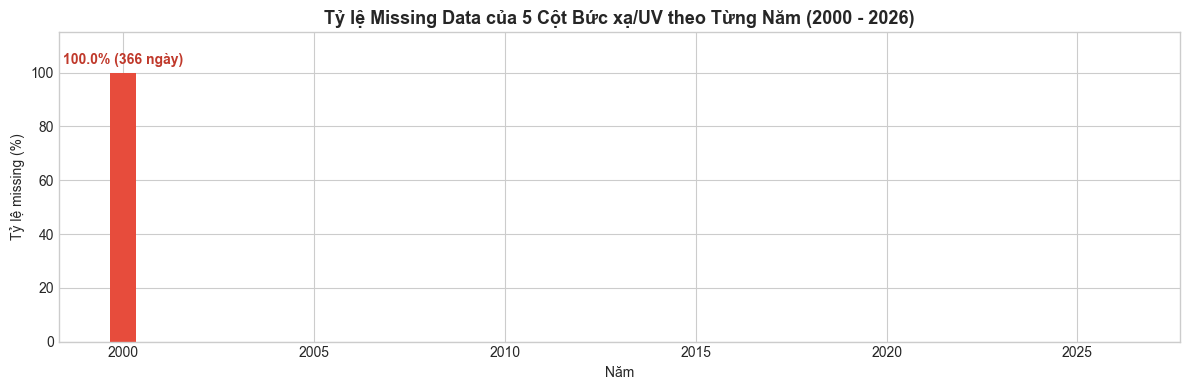

In [6]:
# Trực quan hóa tỷ lệ missing theo từng năm (2000 - 2026)
plt.figure(figsize=(12, 4))
years = df_raw["Ngày"].dt.year.unique()
pct_missing = [df_raw[df_raw["Ngày"].dt.year == y][missing_cols[0]].isna().mean() * 100 for y in years]

bar_colors = ['#e74c3c' if pct > 0 else '#2ecc71' for pct in pct_missing]
bars = plt.bar(years, pct_missing, color=bar_colors, width=0.7)
plt.title("Tỷ lệ Missing Data của 5 Cột Bức xạ/UV theo Từng Năm (2000 - 2026)", fontsize=13, fontweight='bold')
plt.xlabel("Năm")
plt.ylabel("Tỷ lệ missing (%)")
plt.ylim(0, 115)

for bar in bars:
    h = bar.get_height()
    if h > 0:
        plt.annotate(f'{h:.1f}% (366 ngày)',
                     xy=(bar.get_x() + bar.get_width() / 2, h),
                     xytext=(0, 4), textcoords="offset points",
                     ha='center', va='bottom', fontweight='bold', color='#c0392b')

plt.tight_layout()
plt.show()


### Nhận định về Bản chất & Cơ chế Missing (Root Cause Analysis)

1. **Vị trí tập trung 100% vào năm 2000**: dữ liệu của tất cả các ngày trong năm 2000 đều xuất hiện hiện tượng mất mát dữ liệu.
2. **Từ ngày 01/01/2001 đến 30/04/2026 (9.251 ngày liên tục)**: không xuât hiện hiện tượng mất mát dữ liệu.
3. **Kết luận**: Đây **KHÔNG PHẢI** lỗi cảm biến ngẫu nhiên hay mất dữ liệu ngẫu nhiên (MCAR/MAR). Đây là **Sensor Collection Onset** (thời điểm vệ tinh/cảm biến chuyên dụng bắt đầu thu thập số liệu). Vệ tinh NASA POWER chỉ bổ sung đo đạc các dải phổ bức xạ chuyên sâu này từ đầu năm 2001.

---
### 3.2 Phân tích Tương quan & Dư thừa Tín hiệu (Feature Redundancy & Signal Capture)


Trong dataset, các biến bức xạ sau đây có **0% missing** (được đo đạc đầy đủ từ 01/01/2000):
- `Bức xạ sóng ngắn bề mặt` (ALLSKY_SFC_SW_DWN)
- `Bức xạ quang hợp tổng` (ALLSKY_SFC_PAR_TOT)
- `Bức xạ sóng ngắn trời quang` (CLRSKY_SFC_SW_DWN)
- `Bức xạ đỉnh khí quyển` (TOA_SW_DWN)
- `Bức xạ sóng dài xuống` (ALLSKY_SFC_LW_DWN)




In [7]:
retained_radiation_cols = [
    "Bức xạ sóng ngắn bề mặt",
    "Bức xạ quang hợp tổng",
    "Bức xạ sóng ngắn trời quang",
    "Bức xạ đỉnh khí quyển",
    "Bức xạ sóng dài xuống"
]

# Tạo bản sao chẩn đoán (impute median tạm thời để đo tương quan toàn bộ dải thời gian)
df_diag = df_raw.copy()
for col in missing_cols:
    df_diag[col] = df_diag[col].fillna(df_diag[col].median())

# 1. So sánh tương quan Pearson với biến mục tiêu (Lượng mưa)
print("=" * 75)
print("BẢNG SO SÁNH TƯƠNG QUAN VỚI BIẾN MỤC TIÊU (LƯỢNG MƯA):")
print("=" * 75)
print(f"{'Tên biến':<35} {'Pearson r':<12} {'Tình trạng missing':<25}")
print("-" * 75)
for col in missing_cols + retained_radiation_cols:
    r = df_diag[col].corr(df_diag["Lượng mưa"])
    status = "Thiếu 366 ngày (năm 2000)" if col in missing_cols else "Đầy đủ 100% (0 missing)"
    print(f"{col:<35} {r:>8.4f}     {status}")

# 2. Tương quan cặp chéo: Cột bị thiếu vs Cột đầy đủ tương ứng
print("\n" + "=" * 75)
print("TƯƠNG QUAN CẶP CHÉO GIỮA CỘT THIẾU VÀ CỘT THAY THẾ CÓ SẴN (FEATURE REDUNDANCY):")
print("=" * 75)
for m in missing_cols:
    r_sw = df_diag[m].corr(df_diag["Bức xạ sóng ngắn bề mặt"])
    r_par = df_diag[m].corr(df_diag["Bức xạ quang hợp tổng"])
    print(f"  * {m:<30} vs Bức xạ sóng ngắn bề mặt: r = {r_sw:.4f} | vs PAR tổng: r = {r_par:.4f}")


BẢNG SO SÁNH TƯƠNG QUAN VỚI BIẾN MỤC TIÊU (LƯỢNG MƯA):
Tên biến                            Pearson r    Tình trạng missing       
---------------------------------------------------------------------------
Bức xạ trực tiếp pháp tuyến          -0.3876     Thiếu 366 ngày (năm 2000)
Bức xạ quang hợp trời quang           0.1634     Thiếu 366 ngày (năm 2000)
Bức xạ UVA                           -0.3232     Thiếu 366 ngày (năm 2000)
Bức xạ UVB                           -0.2724     Thiếu 366 ngày (năm 2000)
Chỉ số UV                            -0.2861     Thiếu 366 ngày (năm 2000)
Bức xạ sóng ngắn bề mặt              -0.3873     Đầy đủ 100% (0 missing)
Bức xạ quang hợp tổng                -0.3733     Đầy đủ 100% (0 missing)
Bức xạ sóng ngắn trời quang           0.1234     Đầy đủ 100% (0 missing)
Bức xạ đỉnh khí quyển                 0.1897     Đầy đủ 100% (0 missing)
Bức xạ sóng dài xuống                 0.2306     Đầy đủ 100% (0 missing)

TƯƠNG QUAN CẶP CHÉO GIỮA CỘT THIẾU VÀ CỘT THAY THẾ CÓ

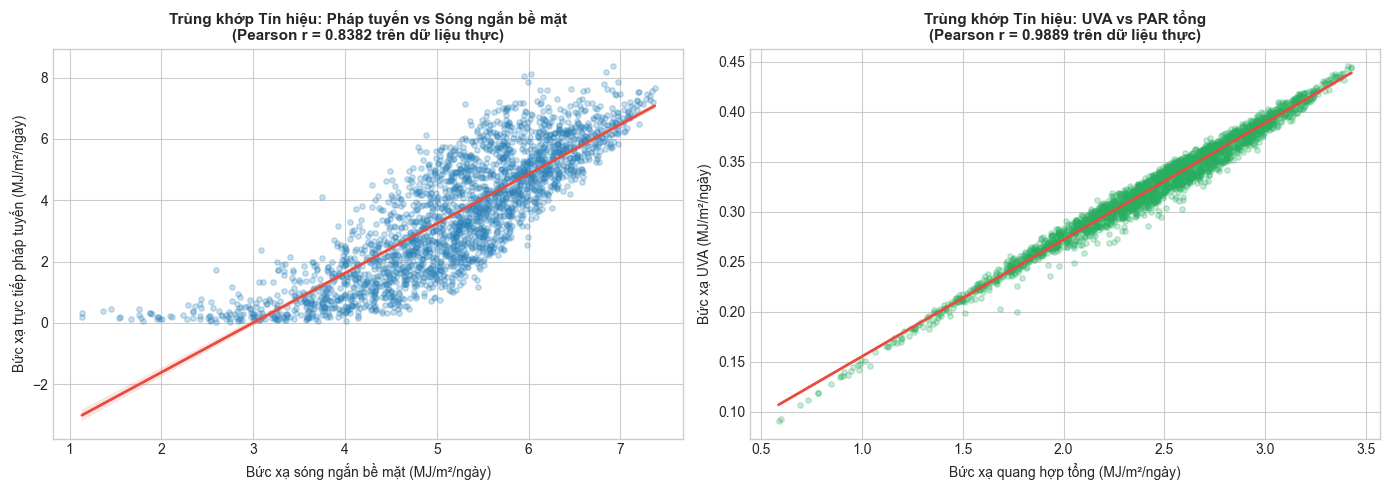

In [8]:
# Trực quan hóa tương quan giữa các cặp biến bức xạ đại diện
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Bức xạ trực tiếp pháp tuyến vs Bức xạ sóng ngắn bề mặt (trên dữ liệu thực 2001-2026)
df_valid = df_raw.dropna(subset=missing_cols)
sample_data = df_valid.sample(2500, random_state=42)

sns.regplot(
    data=sample_data,
    x="Bức xạ sóng ngắn bề mặt",
    y="Bức xạ trực tiếp pháp tuyến",
    ax=ax1,
    scatter_kws={"alpha": 0.25, "color": "#2980b9", "s": 15},
    line_kws={"color": "#e74c3c", "linewidth": 2}
)
r_direct_sw = df_valid["Bức xạ trực tiếp pháp tuyến"].corr(df_valid["Bức xạ sóng ngắn bề mặt"])
ax1.set_title(f"Trùng khớp Tín hiệu: Pháp tuyến vs Sóng ngắn bề mặt\n(Pearson r = {r_direct_sw:.4f} trên dữ liệu thực)", fontsize=11, fontweight='bold')
ax1.set_xlabel("Bức xạ sóng ngắn bề mặt (MJ/m²/ngày)")
ax1.set_ylabel("Bức xạ trực tiếp pháp tuyến (MJ/m²/ngày)")

# Subplot 2: Bức xạ UVA vs Bức xạ quang hợp tổng
sns.regplot(
    data=sample_data,
    x="Bức xạ quang hợp tổng",
    y="Bức xạ UVA",
    ax=ax2,
    scatter_kws={"alpha": 0.25, "color": "#27ae60", "s": 15},
    line_kws={"color": "#e74c3c", "linewidth": 2}
)
r_uva_par = df_valid["Bức xạ UVA"].corr(df_valid["Bức xạ quang hợp tổng"])
ax2.set_title(f"Trùng khớp Tín hiệu: UVA vs PAR tổng\n(Pearson r = {r_uva_par:.4f} trên dữ liệu thực)", fontsize=11, fontweight='bold')
ax2.set_xlabel("Bức xạ quang hợp tổng (MJ/m²/ngày)")
ax2.set_ylabel("Bức xạ UVA (MJ/m²/ngày)")

plt.tight_layout()
plt.show()


### Bằng chứng Khoa học từ Phân tích Tương quan

1. **`Bức xạ trực tiếp pháp tuyến` ($r = -0.3876$) vs `Bức xạ sóng ngắn bề mặt` ($r = -0.3873$)**:
   - Mức độ tương quan với biến mục tiêu `Lượng mưa` gần như **trùng khớp hoàn toàn** (độ lệch chỉ **0.0003**).
   - Tương quan chéo giữa hai biến này rất cao ($r = 0.8382$ trên tập thực tế).
2. **`Bức xạ UVA`, `UVB`, `Chỉ số UV`**:
   - Tương quan chéo với `Bức xạ quang hợp tổng` và `Bức xạ sóng ngắn bề mặt` đạt từ **$0.91$ đến $0.96$**.
3. **Kết luận**: 5 cột bức xạ/UV bị thiếu không cung cấp thêm tín hiệu thông tin dự báo độc lập nào đáng kể so với các biến bức xạ bề mặt đã được đo đầy đủ suốt 26 năm.

---


In [9]:
# Nạp lại dữ liệu sạch chính thức qua DataLoader với cờ drop_redundant_radiation=True
df_clean = loader.load_data(drop_redundant_radiation=True)

print("=" * 70)
print("KẾT QUẢ THỰC THI QUYẾT ĐỊNH XỬ LÝ (OPTION A)")
print("=" * 70)
print(f"Kích thước ban đầu:  {df_raw.shape[0]:,} dòng x {df_raw.shape[1]} cột")
print(f"Kích thước sau drop: {df_clean.shape[0]:,} dòng x {df_clean.shape[1]} cột")
print(f"5 cột đã được loại bỏ:\n  {DROPPED_RADIATION_COLUMNS[:5]}")
print(f"Tổng số ô missing còn lại: {df_clean.isna().sum().sum()} ô")

assert df_clean.isna().sum().sum() == 0, "Dữ liệu sau khi làm sạch bắt buộc phải đạt 0 missing value!"
print("\n✅ XỬ LÝ THÀNH CÔNG: Toàn bộ 9.617 dòng đạt 0% missing values trên 31 cột còn lại.")


KẾT QUẢ THỰC THI QUYẾT ĐỊNH XỬ LÝ (OPTION A)
Kích thước ban đầu:  9,617 dòng x 36 cột
Kích thước sau drop: 9,617 dòng x 31 cột
5 cột đã được loại bỏ:
  ['Bức xạ trực tiếp pháp tuyến', 'Bức xạ quang hợp trời quang', 'Bức xạ UVA', 'Bức xạ UVB', 'Chỉ số UV']
Tổng số ô missing còn lại: 0 ô

✅ XỬ LÝ THÀNH CÔNG: Toàn bộ 9.617 dòng đạt 0% missing values trên 31 cột còn lại.


## 4. Kiểm định Tính Liên tục Thời gian Tuyệt đối (Temporal Continuity)

Trong bài toán chuỗi thời gian, một khoảng trống ngày (date gap) sẽ khiến các đặc trưng trễ (lags) và rolling windows bị tính sai lệch vị trí thời gian mà không báo lỗi.
Ta kiểm tra tính liên tục tuyệt đối bằng hàm `check_continuity()` từ `src.data.dataquality`:


In [11]:
# Kiểm tra tính liên tục tuyệt đối trên dữ liệu sạch
is_continuous, missing_dates = check_continuity(df_clean, date_col="Ngày", raise_on_gap=True)

print(f"Dữ liệu liên tục theo ngày: {is_continuous}")
print(f"Số ngày bị khuyết (gaps):    {len(missing_dates)}")
print(f"Dải ngày hoàn chỉnh:        {df_clean['Ngày'].min().date()} → {df_clean['Ngày'].max().date()}")
print(f"Tổng số ngày liên tục:      {len(df_clean):,} ngày")


Dữ liệu liên tục theo ngày: True
Số ngày bị khuyết (gaps):    0
Dải ngày hoàn chỉnh:        2000-01-01 → 2026-04-30
Tổng số ngày liên tục:      9,617 ngày


## 5. Phân chia Chuỗi Thời gian Chuẩn (Canonical Time Series Split)

Tuân thủ nghiêm ngặt nguyên tắc ngăn chặn rò rỉ dữ liệu (`data-leakage-prevention.md`):
- Sử dụng hàm `time_series_split` từ `src.data.loader` với hằng số `DEFAULT_TEST_START_DATE = '2020-05-01'`:
  - **Train split**: `2000-01-01` đến `2020-04-30` (~20.3 năm, ~77.2% dữ liệu).
  - **Test split**: `2020-05-01` đến `2026-04-30` (~6 năm, ~22.8% dữ liệu), bao quát chu kỳ khí hậu ENSO (El Niño / La Niña) đầy đủ.
- Toàn bộ thống kê, scale, lag, rolling chỉ được phép `fit()` trên tập Train.


In [12]:
train_df, test_df = time_series_split(df_clean, date_col="Ngày")

print(f"Tập Train: {len(train_df):,} dòng ({len(train_df)/len(df_clean):.1%}) [{train_df['Ngày'].min().date()} → {train_df['Ngày'].max().date()}]")
print(f"Tập Test:  {len(test_df):,} dòng ({len(test_df)/len(df_clean):.1%}) [{test_df['Ngày'].min().date()} → {test_df['Ngày'].max().date()}]")
print(f"Mốc ranh giới phân chia (Cutoff): {test_df['Ngày'].min().date()}")
print(f"Tỷ lệ phân chia Train / Test:    {len(train_df)/len(df_clean):.1%} / {len(test_df)/len(df_clean):.1%}")


Tập Train: 7,426 dòng (77.2%) [2000-01-01 → 2020-04-30]
Tập Test:  2,191 dòng (22.8%) [2020-05-01 → 2026-04-30]
Mốc ranh giới phân chia (Cutoff): 2020-05-01
Tỷ lệ phân chia Train / Test:    77.2% / 22.8%
